# Local static-dynamic Dynamical Similarity Analysis

This notebook compares one local static transition with one local dynamic transition using Dynamical Similarity Analysis (DSA) from Ostrow et al. (2023), *Beyond Geometry*. The workflow is:

1. Compute a cross-temporal dRSA matrix to select corresponding static and dynamic response timepoints.
2. Fit a local transition $z(t + \Delta t) = A z(t)$ at every valid timepoint and visualize the full cross-temporal DSA matrix.
3. At the selected static and dynamic timepoints, inspect the reduced-rank HAVOK transitions in detail.
4. Optionally define each state with a delay embedding $[x(t-(p-1)\tau), \ldots, x(t)]$.
5. Visualize the two selected transition matrices as 2D vector fields, where arrows show $(A-I)z$.
6. Compute Procrustes Analysis over Vector Fields: $\min_{C\in O(r)} \lVert A_s-C A_d C^{-1}\rVert_F$.
7. Compare static-dynamic DSA with a within-dynamic split-half reliability distribution.

The implementation follows equations 3, 5, and 6 of [Ostrow et al. (2023)](https://arxiv.org/abs/2306.10168) and mirrors the authors' HAVOK convention: `n_delays=1` means no delay embedding. Because this is a *local* analysis, every stimulus repetition contributes exactly one transition at the selected timepoint; trial boundaries are never joined.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'config.yaml').is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError('Could not find config.yaml above the notebook directory.')
    # end if PROJECT_ROOT.parent
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open
paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from project_specific_utils import (
    average_presentations, compute_rdm_timeseries,
    cross_temporal_similarity, load_raster,
)
from project_specific_utils.dynamical_similarity import (
    compute_cross_temporal_dsa, compute_split_half_dsa, fit_local_dmd,
    procrustes_vector_fields, vector_field_grid,
)
from useful_stuff.general_utils import TimeSeries

## 1. Analysis configuration

Run the notebook once with `static_time_ms=None` and `dynamic_time_ms=None` to mark the best dRSA pair inside the selection windows. After inspecting the heatmap, enter the desired times in milliseconds and rerun from the timepoint-selection cell. Set `n_delays=1` for ordinary local DMD or a value larger than one for HAVOK delay embeddings.

In [28]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27" #'red_20260726to27'
    dynamic_exp_name: str = "baby1_260716to24" # 'red_20260720to24'
    static_response: str = 'last_frame'  # last_frame, 2000ms, or 2250ms

    # Inclusive one-based MATLAB channels, or top_k dynamic-responsive channels.
    good_channels: tuple[int, int] | None = (101,109) #None
    top_k: int | None = None # 50
    static_crop_ms: float = 1000
    dynamic_crop_ms: float | None = None
    source_fs: float = 1000
    new_fs: float = 100

    rdm_metric: str = 'cosine_cnt'
    rsa_metric: str = 'correlation'
    static_selection_window_ms: tuple[float, float] = (100, 900)
    dynamic_selection_window_ms: tuple[float, float] = (1500, 3200)
    static_time_ms: float | None = 200
    dynamic_time_ms: float | None = 2500

    dmd_rank: int = 2
    n_delays: int = 5  # 1 disables delay embedding.
    delay_interval: int = 1
    steps_ahead: int = 1
    dmd_ridge: float = 1e-8

    pavf_iterations: int = 400
    pavf_learning_rate: float = 0.01
    pavf_restarts: int = 4

    # Cross-temporal DSA: stride=1 evaluates every resampled timepoint.
    cross_dsa_stride: int = 1
    cross_dsa_iterations: int = 100
    cross_dsa_batch_size: int = 512
    n_split_repeats: int = 10
    random_seed: int = 0
    device: str = 'cpu'


cfg = Cfg()
cfg

Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', static_response='last_frame', good_channels=(101, 109), top_k=None, static_crop_ms=1000, dynamic_crop_ms=None, source_fs=1000, new_fs=100, rdm_metric='cosine_cnt', rsa_metric='correlation', static_selection_window_ms=(100, 900), dynamic_selection_window_ms=(1500, 3200), static_time_ms=200, dynamic_time_ms=2500, dmd_rank=2, n_delays=5, delay_interval=1, steps_ahead=1, dmd_ridge=1e-08, pavf_iterations=400, pavf_learning_rate=0.01, pavf_restarts=4, cross_dsa_stride=1, cross_dsa_iterations=100, cross_dsa_batch_size=512, n_split_repeats=10, random_seed=0, device='cpu')

## 2. Load, match, select channels, and resample repetitions

The `raster` files retain individual presentations, which are required both for a local transition fit across trials and for genuine split-half reliability. Static and dynamic presentations are matched by stimulus identity. Channel selection is performed once on the full matched dynamic dataset, then applied identically to both conditions.

In [3]:
"""
stimulus_identity
Extract the matched stimulus identity for one configured condition.

INPUT:
    - name: str -> presentation filename
    - condition: str -> static or dynamic
    - static_response: str -> retained static-image control

OUTPUT:
    - identity: str | None -> shared identity or None when excluded
"""
def stimulus_identity(name, condition, static_response):
    stem = Path(name).stem
    if condition == 'static':
        static_prefixes = {
            'last_frame': 'img_',
            '2000ms': 'img_2000ms_',
            '2250ms': 'img_2250ms_',
        }
        if stem.startswith(static_prefixes['2000ms']):
            response = '2000ms'
        elif stem.startswith(static_prefixes['2250ms']):
            response = '2250ms'
        elif stem.startswith(static_prefixes['last_frame']):
            response = 'last_frame'
        else:
            return None
        # end if static prefix
        if response != static_response:
            return None
        # end if response != static_response
        prefix = static_prefixes[response]
    elif condition == 'dynamic':
        prefix = 'vid_'
    else:
        raise ValueError("condition must be 'static' or 'dynamic'.")
    # end if condition
    return stem[len(prefix):] if stem.startswith(prefix) else None
# EOF


def resample_rasters(rasters, source_fs, target_fs):
    """Resample channels x time x presentations with TimeSeries."""
    if source_fs == target_fs:
        return rasters
    # end if source_fs == target_fs
    time_series = TimeSeries(rasters, fs=source_fs)
    time_series.resample(target_fs)
    return time_series.get_array()
# EOF

In [4]:
valid_static_responses = {'last_frame', '2000ms', '2250ms'}
if cfg.static_response not in valid_static_responses:
    raise ValueError(f'static_response must be one of {sorted(valid_static_responses)}.')
# end if cfg.static_response

data_dir = Path(paths['data_path']) / 'data'
static_path = data_dir / f'{cfg.static_exp_name}_raster_img.mat'
dynamic_path = data_dir / f'{cfg.dynamic_exp_name}_raster_vid.mat'
static_end_sample = int(round(cfg.static_crop_ms * cfg.source_fs / 1000))
dynamic_end_sample = (
    None if cfg.dynamic_crop_ms is None
    else int(round(cfg.dynamic_crop_ms * cfg.source_fs / 1000))
)

# Load all channels when top-k selection must be estimated from the data.
if cfg.good_channels is None:
    channel_slice = slice(None)
else:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
# end if cfg.good_channels

static_rasters, static_names = load_raster(
    static_path, channel_slice=channel_slice, end_sample=static_end_sample,
)
dynamic_rasters, dynamic_names = load_raster(
    dynamic_path, channel_slice=channel_slice, end_sample=dynamic_end_sample,
)

static_ids = [
    stimulus_identity(name, 'static', cfg.static_response)
    for name in static_names
]
dynamic_ids = [
    stimulus_identity(name, 'dynamic', cfg.static_response)
    for name in dynamic_names
]
shared_stimuli = sorted(
    {identity for identity in static_ids if identity is not None}
    & {identity for identity in dynamic_ids if identity is not None}
)
if len(shared_stimuli) < 3:
    raise ValueError('Need at least three shared stimuli.')
# end if len(shared_stimuli)

shared_set = set(shared_stimuli)
static_keep = np.asarray([identity in shared_set for identity in static_ids])
dynamic_keep = np.asarray([identity in shared_set for identity in dynamic_ids])
static_rasters = static_rasters[:, :, static_keep]
dynamic_rasters = dynamic_rasters[:, :, dynamic_keep]
static_ids = [identity for identity, keep in zip(static_ids, static_keep) if keep]
dynamic_ids = [identity for identity, keep in zip(dynamic_ids, dynamic_keep) if keep]

if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_numbers = np.arange(first_channel, last_channel + 1)
elif cfg.top_k is not None:
    if not 1 <= cfg.top_k <= dynamic_rasters.shape[0]:
        raise ValueError('top_k is outside the available channel range.')
    # end if cfg.top_k
    excitation_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(excitation_scores)[-cfg.top_k:][::-1]
    static_rasters = static_rasters[channel_indices]
    dynamic_rasters = dynamic_rasters[channel_indices]
    channel_numbers = channel_indices + 1
else:
    channel_numbers = np.arange(1, dynamic_rasters.shape[0] + 1)
# end if cfg.good_channels

static_rasters = resample_rasters(static_rasters, cfg.source_fs, cfg.new_fs)
dynamic_rasters = resample_rasters(dynamic_rasters, cfg.source_fs, cfg.new_fs)
static_times_ms = np.arange(static_rasters.shape[1]) * 1000 / cfg.new_fs
dynamic_times_ms = np.arange(dynamic_rasters.shape[1]) * 1000 / cfg.new_fs

print(f'Shared stimuli: {len(shared_stimuli)}')
print(f'Static repetitions: {static_rasters.shape}')
print(f'Dynamic repetitions: {dynamic_rasters.shape}')
print(f'MATLAB channels: {channel_numbers.tolist()}')
print(f'Resampled interval: {1000 / cfg.new_fs:g} ms')

Shared stimuli: 100
Static repetitions: (9, 100, 3437)
Dynamic repetitions: (9, 350, 2733)
MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Resampled interval: 10 ms


## 3. Compute and visualize cross-temporal dRSA

Repetitions are averaged within stimulus only for timepoint selection. At every timepoint, the neural channel patterns define a condensed stimulus RDM; every dynamic RDM is then correlated with every static RDM. The DMD analysis below returns to the unaveraged repetitions.

In [29]:
static_means = average_presentations(static_rasters, static_ids, shared_stimuli)
dynamic_means = average_presentations(dynamic_rasters, dynamic_ids, shared_stimuli)
static_rdms = compute_rdm_timeseries(static_means, cfg.rdm_metric)
dynamic_rdms = compute_rdm_timeseries(dynamic_means, cfg.rdm_metric)

# Rows are dynamic timepoints; columns are static timepoints.
drsa_similarity = cross_temporal_similarity(
    dynamic_rdms, static_rdms, metric=cfg.rsa_metric,
)
print(f'dRSA matrix: {drsa_similarity.shape} (dynamic time x static time)')

dRSA matrix: (350, 100) (dynamic time x static time)


In [30]:
# Find an automatic candidate only inside scientifically plausible windows.
static_window = (
    (static_times_ms >= cfg.static_selection_window_ms[0])
    & (static_times_ms <= cfg.static_selection_window_ms[1])
)
dynamic_window = (
    (dynamic_times_ms >= cfg.dynamic_selection_window_ms[0])
    & (dynamic_times_ms <= cfg.dynamic_selection_window_ms[1])
)
selection_mask = dynamic_window[:, None] & static_window[None, :]
selection_values = np.where(selection_mask, drsa_similarity, np.nan)
candidate_dynamic_index, candidate_static_index = np.unravel_index(
    np.nanargmax(selection_values), selection_values.shape,
)

# Explicit Cfg times override the automatic dRSA candidate.
selected_static_index = (
    candidate_static_index if cfg.static_time_ms is None
    else int(np.argmin(np.abs(static_times_ms - cfg.static_time_ms)))
)
selected_dynamic_index = (
    candidate_dynamic_index if cfg.dynamic_time_ms is None
    else int(np.argmin(np.abs(dynamic_times_ms - cfg.dynamic_time_ms)))
)
selected_static_ms = static_times_ms[selected_static_index]
selected_dynamic_ms = dynamic_times_ms[selected_dynamic_index]

# A valid local transition needs all delayed history and its future target.
history_samples = (cfg.n_delays - 1) * cfg.delay_interval
for condition, index, n_timepoints in (
        ('static', selected_static_index, static_rasters.shape[1]),
        ('dynamic', selected_dynamic_index, dynamic_rasters.shape[1]),
        ):
    if index - history_samples < 0 or index + cfg.steps_ahead >= n_timepoints:
        raise ValueError(
            f'The selected {condition} time lacks the requested DMD history/future.'
        )
    # end if local transition bounds
# end for condition

print(
    f'Automatic dRSA candidate: static {static_times_ms[candidate_static_index]:g} ms, '
    f'dynamic {dynamic_times_ms[candidate_dynamic_index]:g} ms, '
    f'r = {drsa_similarity[candidate_dynamic_index, candidate_static_index]:.3f}'
)
print(
    f'Selected pair: static {selected_static_ms:g} ms, dynamic {selected_dynamic_ms:g} ms, '
    f'r = {drsa_similarity[selected_dynamic_index, selected_static_index]:.3f}'
)

Automatic dRSA candidate: static 460 ms, dynamic 2670 ms, r = 0.702
Selected pair: static 200 ms, dynamic 2500 ms, r = 0.616


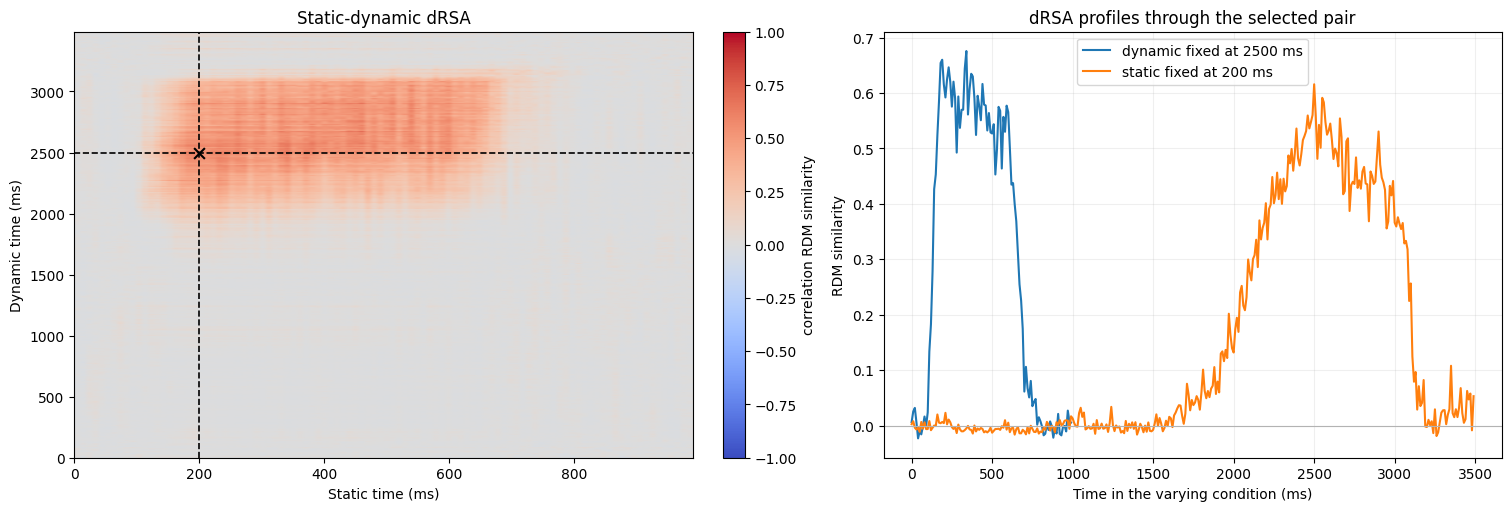

In [31]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
image = axes[0].imshow(
    drsa_similarity, origin='lower', aspect='auto', cmap='coolwarm',
    vmin=-1, vmax=1,
    extent=(
        static_times_ms[0], static_times_ms[-1],
        dynamic_times_ms[0], dynamic_times_ms[-1],
    ),
)
axes[0].axvline(selected_static_ms, color='black', linestyle='--', linewidth=1.2)
axes[0].axhline(selected_dynamic_ms, color='black', linestyle='--', linewidth=1.2)
axes[0].scatter(selected_static_ms, selected_dynamic_ms, marker='x', color='black', s=60)
axes[0].set(
    title='Static-dynamic dRSA', xlabel='Static time (ms)', ylabel='Dynamic time (ms)',
)
figure.colorbar(image, ax=axes[0], label=f'{cfg.rsa_metric} RDM similarity')

axes[1].plot(
    static_times_ms, drsa_similarity[selected_dynamic_index],
    color='tab:blue', label=f'dynamic fixed at {selected_dynamic_ms:g} ms',
)
axes[1].plot(
    dynamic_times_ms, drsa_similarity[:, selected_static_index],
    color='tab:orange', label=f'static fixed at {selected_static_ms:g} ms',
)
axes[1].axhline(0, color='0.7', linewidth=0.8)
axes[1].set(
    title='dRSA profiles through the selected pair',
    xlabel='Time in the varying condition (ms)', ylabel='RDM similarity',
)
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.show()

## 4. Compute cross-temporal DSA

This is the dynamical analogue of the dRSA matrix above. One local HAVOK/DMD transition is fitted at every valid static and dynamic timepoint, after which every static transition matrix is compared with every dynamic transition matrix using the same $C A C^{-1}$ Procrustes Analysis over Vector Fields. Rows are dynamic input-state times and columns are static input-state times.

The local DMDs are fitted only once per timepoint. PAVF comparisons are then optimized in batches, using SVD-informed initializations in both components of $O(r)$. `cross_dsa_stride=1` evaluates every resampled timepoint; increase it only when a faster exploratory scan is desired. The scan uses fewer optimizer iterations than the final selected-pair analysis, so the selected pair is still recomputed below with the higher-precision settings.

In [32]:
if not isinstance(cfg.cross_dsa_stride, int) or cfg.cross_dsa_stride < 1:
    raise ValueError('cross_dsa_stride must be a positive integer.')
# end if cfg.cross_dsa_stride

history_samples = (cfg.n_delays - 1) * cfg.delay_interval
static_dsa_time_indices = np.arange(
    history_samples, static_rasters.shape[1] - cfg.steps_ahead,
    cfg.cross_dsa_stride, dtype=int,
)
dynamic_dsa_time_indices = np.arange(
    history_samples, dynamic_rasters.shape[1] - cfg.steps_ahead,
    cfg.cross_dsa_stride, dtype=int,
)

cross_temporal_dsa = compute_cross_temporal_dsa(
    static_rasters, dynamic_rasters,
    static_time_indices=static_dsa_time_indices,
    dynamic_time_indices=dynamic_dsa_time_indices,
    rank=cfg.dmd_rank, n_delays=cfg.n_delays,
    delay_interval=cfg.delay_interval, steps_ahead=cfg.steps_ahead,
    ridge=cfg.dmd_ridge, pavf_iterations=cfg.cross_dsa_iterations,
    pavf_learning_rate=cfg.pavf_learning_rate,
    pavf_batch_size=cfg.cross_dsa_batch_size, device=cfg.device,
)
cross_static_times_ms = static_times_ms[cross_temporal_dsa.static_time_indices]
cross_dynamic_times_ms = dynamic_times_ms[cross_temporal_dsa.dynamic_time_indices]

selected_cross_static = int(np.argmin(np.abs(cross_static_times_ms - selected_static_ms)))
selected_cross_dynamic = int(np.argmin(np.abs(cross_dynamic_times_ms - selected_dynamic_ms)))
selected_scan_distance = cross_temporal_dsa.angular_distances[
    selected_cross_dynamic, selected_cross_static,
]
print(
    f'Cross-temporal DSA matrix: {cross_temporal_dsa.angular_distances.shape} '
    f'(dynamic time x static time)'
)
print(
    f'Scan value nearest the selected pair: {selected_scan_distance:.4f} rad; '
    f'normalized similarity {1 - selected_scan_distance / np.pi:.4f}'
)

Cross-temporal DSA matrix: (345, 95) (dynamic time x static time)
Scan value nearest the selected pair: 0.2909 rad; normalized similarity 0.9074


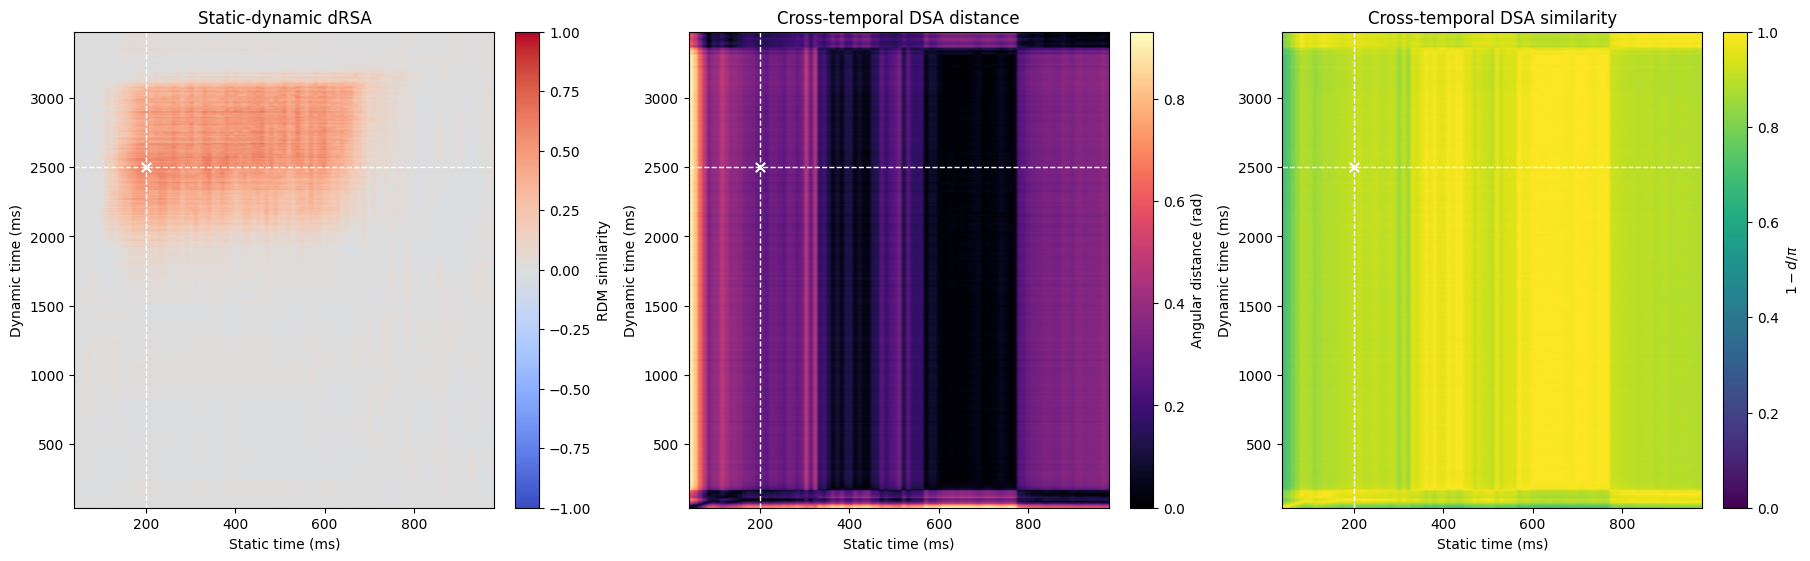

In [33]:
# Restrict dRSA to the exact time grid used by the local DSA scan.
drsa_on_dsa_grid = drsa_similarity[np.ix_(
    cross_temporal_dsa.dynamic_time_indices,
    cross_temporal_dsa.static_time_indices,
)]
plot_extent = (
    cross_static_times_ms[0], cross_static_times_ms[-1],
    cross_dynamic_times_ms[0], cross_dynamic_times_ms[-1],
)

figure, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
matrix_specs = (
    (drsa_on_dsa_grid, 'Static-dynamic dRSA', 'coolwarm', -1, 1, 'RDM similarity'),
    (cross_temporal_dsa.angular_distances, 'Cross-temporal DSA distance', 'magma', 0, None, 'Angular distance (rad)'),
    (cross_temporal_dsa.normalized_similarities, 'Cross-temporal DSA similarity', 'viridis', 0, 1, '$1-d/\\pi$'),
)
for axis, (matrix, title, cmap, vmin, vmax, colorbar_label) in zip(axes, matrix_specs):
    image = axis.imshow(
        matrix, origin='lower', aspect='auto', cmap=cmap,
        vmin=vmin, vmax=vmax, extent=plot_extent,
    )
    axis.axvline(selected_static_ms, color='white', linestyle='--', linewidth=1)
    axis.axhline(selected_dynamic_ms, color='white', linestyle='--', linewidth=1)
    axis.scatter(selected_static_ms, selected_dynamic_ms, marker='x', color='white', s=45)
    axis.set(title=title, xlabel='Static time (ms)', ylabel='Dynamic time (ms)')
    figure.colorbar(image, ax=axis, label=colorbar_label)
# end for axis, matrix
plt.show()

## 5. Fit one local HAVOK/DMD transition per condition

For each condition, the selected local window is delay-embedded independently within each repetition. The flattened Hankel matrix is decomposed as $H^T=U\Sigma V^T$ and the first `dmd_rank` eigen-time-delay coordinates are retained. Ridge least squares then fits $V_r(t+\Delta t)=A V_r(t)$. The same rank is mandatory because PAVF compares two square matrices of equal size.

In [34]:
static_dmd = fit_local_dmd(
    static_rasters, time_index=selected_static_index, rank=cfg.dmd_rank,
    n_delays=cfg.n_delays, delay_interval=cfg.delay_interval,
    steps_ahead=cfg.steps_ahead, ridge=cfg.dmd_ridge,
)
dynamic_dmd = fit_local_dmd(
    dynamic_rasters, time_index=selected_dynamic_index, rank=cfg.dmd_rank,
    n_delays=cfg.n_delays, delay_interval=cfg.delay_interval,
    steps_ahead=cfg.steps_ahead, ridge=cfg.dmd_ridge,
)

for condition, result in (('Static', static_dmd), ('Dynamic', dynamic_dmd)):
    retained_variance = result.cumulative_explained_variance[cfg.dmd_rank - 1]
    print(
        f'{condition}: A {result.transition_matrix.shape}, '
        f'HAVOK variance {retained_variance:.1%}, '
        f'one-step R2 {result.prediction_r2:.3f}, MSE {result.prediction_mse:.3g}'
    )
# end for condition

print('\nStatic transition matrix A_s:')
print(np.array2string(static_dmd.transition_matrix, precision=3, suppress_small=True))
print('\nDynamic transition matrix A_d:')
print(np.array2string(dynamic_dmd.transition_matrix, precision=3, suppress_small=True))

Static: A (2, 2), HAVOK variance 56.0%, one-step R2 0.542, MSE 4.59e-05
Dynamic: A (2, 2), HAVOK variance 37.5%, one-step R2 0.874, MSE 1.82e-05

Static transition matrix A_s:
[[ 0.989 -0.091]
 [ 0.136  0.542]]

Dynamic transition matrix A_d:
[[ 0.978 -0.005]
 [-0.01   0.925]]


## 6. Visualize both transition matrices as 2D vector fields

The first two HAVOK coordinates define each displayed plane. At a grid state $z$, the arrow is the discrete displacement $A z-z$. Higher coordinates are fixed at zero. These plots are projections for interpretation; the DSA score uses the complete rank-by-rank matrices.

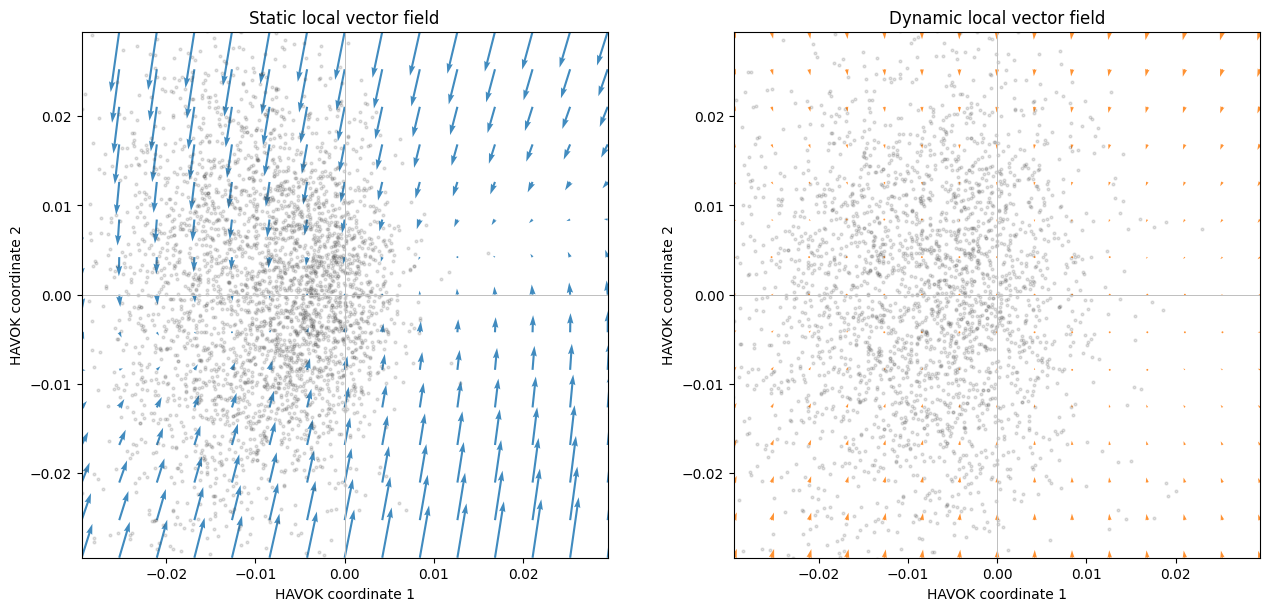

In [35]:
# Use identical state-space limits and arrow scaling in both panels.
combined_coordinates = np.vstack([
    static_dmd.current_coordinates, dynamic_dmd.current_coordinates,
])
figure, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

for axis, condition, result, color in (
        (axes[0], 'Static', static_dmd, 'tab:blue'),
        (axes[1], 'Dynamic', dynamic_dmd, 'tab:orange'),
        ):
    x_grid, y_grid, u_grid, v_grid = vector_field_grid(
        result.transition_matrix, combined_coordinates, grid_size=15,
    )
    axis.quiver(
        x_grid, y_grid, u_grid, v_grid, color=color, alpha=0.85,
        angles='xy', scale_units='xy', scale=2.5, width=0.004,
    )
    axis.scatter(
        result.current_coordinates[:, 0], result.current_coordinates[:, 1],
        s=4, color='0.25', alpha=0.15, rasterized=True,
    )
    axis.axhline(0, color='0.75', linewidth=0.7)
    axis.axvline(0, color='0.75', linewidth=0.7)
    axis.set(
        title=f'{condition} local vector field',
        xlabel='HAVOK coordinate 1', ylabel='HAVOK coordinate 2',
    )
    axis.set_xlim(x_grid.min(), x_grid.max())
    axis.set_ylim(y_grid.min(), y_grid.max())
    axis.set_aspect('equal', adjustable='box')
# end for axis, condition
plt.show()

## 7. Compare vector fields with $C A C^{-1}$ Procrustes alignment

The optimizer parameterizes orthogonal matrices with the Cayley map and evaluates both disconnected components of $O(r)$ (rotations and reflections), as described in the paper's supplement. The primary paper metric is angular distance in radians (lower is more similar, range $[0,\pi]$). For readability, the notebook also reports cosine similarity and $1-d/\pi$ (higher is more similar).

In [36]:
static_dynamic_pavf = procrustes_vector_fields(
    static_dmd.transition_matrix, dynamic_dmd.transition_matrix,
    n_iterations=cfg.pavf_iterations,
    learning_rate=cfg.pavf_learning_rate,
    n_restarts=cfg.pavf_restarts,
    random_seed=cfg.random_seed,
    device=cfg.device,
)

print(f'PAVF angular distance: {static_dynamic_pavf.angular_distance:.4f} rad')
print(f'PAVF cosine similarity: {static_dynamic_pavf.cosine_similarity:.4f}')
print(f'PAVF normalized similarity (1 - angle/pi): {static_dynamic_pavf.normalized_similarity:.4f}')
print(f'Normalized Frobenius distance: {static_dynamic_pavf.normalized_frobenius_distance:.4f}')

PAVF angular distance: 0.2909 rad
PAVF cosine similarity: 0.9580
PAVF normalized similarity (1 - angle/pi): 0.9074
Normalized Frobenius distance: 0.2899


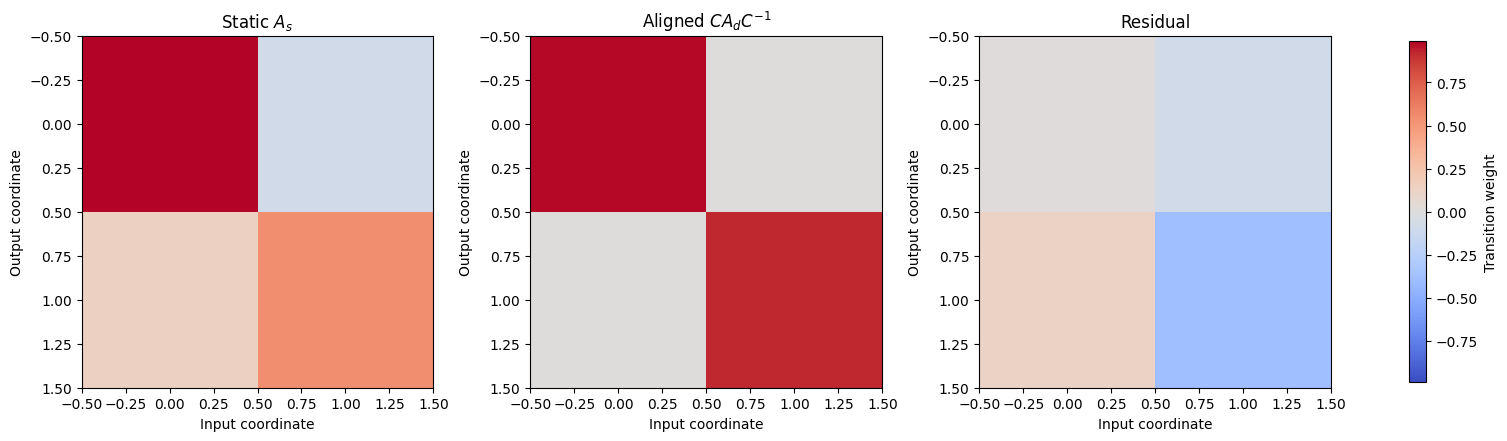

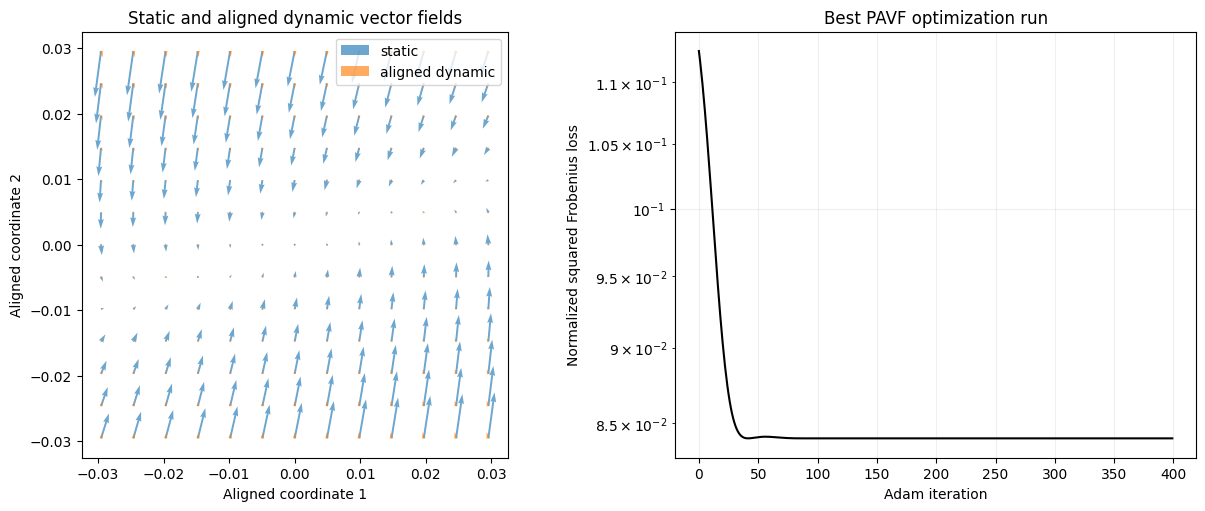

In [37]:
aligned_dynamic_coordinates = (
    dynamic_dmd.current_coordinates @ static_dynamic_pavf.transformation.T
)
matrix_difference = (
    static_dmd.transition_matrix - static_dynamic_pavf.aligned_matrix
)
matrix_limit = max(
    np.abs(static_dmd.transition_matrix).max(),
    np.abs(static_dynamic_pavf.aligned_matrix).max(),
)

figure, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for axis, matrix, title in (
        (axes[0], static_dmd.transition_matrix, 'Static $A_s$'),
        (axes[1], static_dynamic_pavf.aligned_matrix, 'Aligned $C A_d C^{-1}$'),
        (axes[2], matrix_difference, 'Residual'),
        ):
    image = axis.imshow(matrix, cmap='coolwarm', vmin=-matrix_limit, vmax=matrix_limit)
    axis.set(title=title, xlabel='Input coordinate', ylabel='Output coordinate')
# end for axis, matrix
figure.colorbar(image, ax=axes, shrink=0.8, label='Transition weight')
plt.show()

# Overlay the aligned dynamic field on the static field in one common basis.
aligned_coordinates = np.vstack([
    static_dmd.current_coordinates, aligned_dynamic_coordinates,
])
figure, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for matrix, coordinates, color, label in (
        (static_dmd.transition_matrix, static_dmd.current_coordinates, 'tab:blue', 'static'),
        (static_dynamic_pavf.aligned_matrix, aligned_dynamic_coordinates, 'tab:orange', 'aligned dynamic'),
        ):
    x_grid, y_grid, u_grid, v_grid = vector_field_grid(
        matrix, aligned_coordinates, grid_size=13,
    )
    axes[0].quiver(
        x_grid, y_grid, u_grid, v_grid, color=color, alpha=0.65,
        angles='xy', scale_units='xy', scale=2.5, label=label,
    )
# end for matrix, coordinates
axes[0].set(
    title='Static and aligned dynamic vector fields',
    xlabel='Aligned coordinate 1', ylabel='Aligned coordinate 2',
)
axes[0].set_aspect('equal', adjustable='box')
axes[0].legend()
axes[1].plot(static_dynamic_pavf.loss_curve, color='black')
axes[1].set(
    title='Best PAVF optimization run', xlabel='Adam iteration',
    ylabel='Normalized squared Frobenius loss',
)
axes[1].set_yscale('log')
axes[1].grid(alpha=0.2)
plt.show()

## 8. Dynamic split-half DSA reliability

Each repeat randomly divides presentations *within every dynamic stimulus* without averaging them. A local DMD is fit independently to each half at the selected dynamic timepoint, and the two transition matrices are compared with the same rank, delay embedding, optimizer, and PAVF metric used above. This distribution is an empirical within-condition ceiling for the static-dynamic score; it is not a formal null distribution.

In [38]:
dynamic_split_half = compute_split_half_dsa(
    dynamic_rasters, dynamic_ids, shared_stimuli,
    time_index=selected_dynamic_index, rank=cfg.dmd_rank,
    n_split_repeats=cfg.n_split_repeats, random_seed=cfg.random_seed,
    n_delays=cfg.n_delays, delay_interval=cfg.delay_interval,
    steps_ahead=cfg.steps_ahead, ridge=cfg.dmd_ridge,
    pavf_iterations=cfg.pavf_iterations,
    pavf_learning_rate=cfg.pavf_learning_rate,
    pavf_restarts=cfg.pavf_restarts, device=cfg.device,
)

angle_interval = np.percentile(dynamic_split_half.angular_distances, [2.5, 97.5])
similarity_interval = np.percentile(dynamic_split_half.normalized_similarities, [2.5, 97.5])
print(
    f'Dynamic split-half angular distance: median '
    f'{np.median(dynamic_split_half.angular_distances):.4f} rad, '
    f'95% empirical interval [{angle_interval[0]:.4f}, {angle_interval[1]:.4f}]'
)
print(
    f'Dynamic split-half normalized similarity: median '
    f'{np.median(dynamic_split_half.normalized_similarities):.4f}, '
    f'95% empirical interval [{similarity_interval[0]:.4f}, {similarity_interval[1]:.4f}]'
)
print(
    'Static-dynamic angle percentile within split-half distances: '
    f'{100 * np.mean(dynamic_split_half.angular_distances <= static_dynamic_pavf.angular_distance):.1f}%'
)

Dynamic split-half angular distance: median 0.0099 rad, 95% empirical interval [0.0065, 0.0231]
Dynamic split-half normalized similarity: median 0.9968, 95% empirical interval [0.9927, 0.9979]
Static-dynamic angle percentile within split-half distances: 100.0%


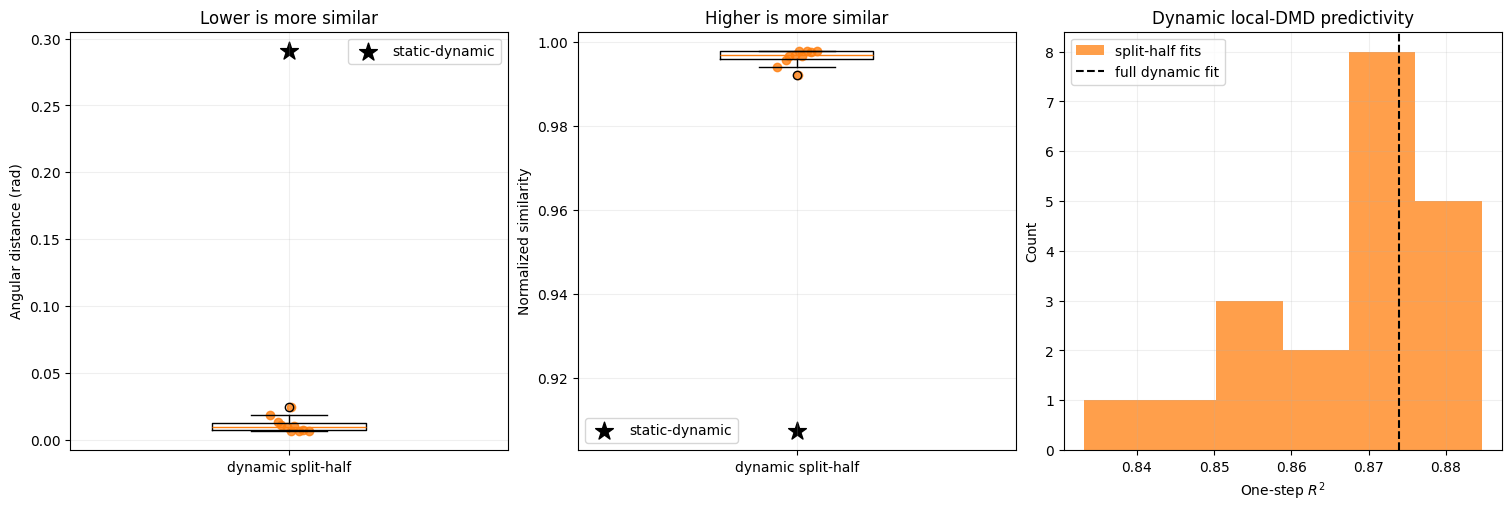

In [39]:
rng = np.random.default_rng(cfg.random_seed)
jitter = rng.normal(scale=0.035, size=cfg.n_split_repeats)
figure, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

axes[0].boxplot(dynamic_split_half.angular_distances, positions=[1], widths=0.35)
axes[0].scatter(1 + jitter, dynamic_split_half.angular_distances, color='tab:orange', alpha=0.8)
axes[0].scatter(1, static_dynamic_pavf.angular_distance, marker='*', s=180, color='black', label='static-dynamic')
axes[0].set(xticks=[1], xticklabels=['dynamic split-half'], ylabel='Angular distance (rad)', title='Lower is more similar')
axes[0].legend()

axes[1].boxplot(dynamic_split_half.normalized_similarities, positions=[1], widths=0.35)
axes[1].scatter(1 + jitter, dynamic_split_half.normalized_similarities, color='tab:orange', alpha=0.8)
axes[1].scatter(1, static_dynamic_pavf.normalized_similarity, marker='*', s=180, color='black', label='static-dynamic')
axes[1].set(xticks=[1], xticklabels=['dynamic split-half'], ylabel='Normalized similarity', title='Higher is more similar')
axes[1].legend()

half_r2 = np.concatenate([
    dynamic_split_half.first_prediction_r2, dynamic_split_half.second_prediction_r2,
])
axes[2].hist(half_r2, bins='auto', color='tab:orange', alpha=0.75, label='split-half fits')
axes[2].axvline(dynamic_dmd.prediction_r2, color='black', linestyle='--', label='full dynamic fit')
axes[2].set(title='Dynamic local-DMD predictivity', xlabel='One-step $R^2$', ylabel='Count')
axes[2].legend()
for axis in axes:
    axis.grid(alpha=0.2)
# end for axis
plt.show()

## Interpretation checklist

- Confirm that the selected dRSA pair is a meaningful local maximum and not a boundary artifact.
- Confirm that both local DMD fits have useful one-step predictivity and that the retained HAVOK variance is adequate.
- Treat the full rank-by-rank PAVF score as the analysis; the 2D fields are projections only.
- Compare static-dynamic angular distance with the dynamic split-half distribution on the same scale. A cross-condition value near the split-half ceiling supports similar local dynamics; a larger distance can reflect genuine condition differences or estimation noise.
- Repeat across plausible `dmd_rank`, `n_delays`, `delay_interval`, and timepoint choices before drawing a scientific conclusion.